# Fase 2 — Uma metodologia própria: dá para superar o gradient boosting?

A fase 1 testou três metodologias consagradas (M5/gradient boosting, *entity embeddings*, TCN) e **nenhuma rede superou o *baseline*** — gradient boosting 0,610, MLP 0,613, TCN 0,655 de RMSSE. A pergunta natural é: e se, em vez de replicar as referências, construíssemos uma **metodologia própria**? Há alguma sacada que vença o GBM?

Esta fase responde com rigor, e a resposta tem duas partes. Primeiro **por que** o empate acontece — e a explicação não está nos modelos, está no **dado**. Depois, a única brecha teórica que sobra, e uma rede desenhada sob medida para explorá-la.

> **Referência:** Wen, R. et al. (2017). *A Multi-Horizon Quantile Recurrent Forecaster.* arXiv:1711.11053. [PDF](referencias/Wen2017_MQ-RNN_multiQuantile.pdf) · base teórica: Koenker & Bassett (1978), *Regression Quantiles*. Ficha em [`referencias/Fase2-metodologiaPropria.md`](referencias/Fase2-metodologiaPropria.md).

## 1. Onde está o teto? A acurácia de ponto é limitada por ruído

Antes de tentar vencer, é preciso saber quanto sinal ainda existe para extrair. Se o gerador do dataset injetou ruído aleatório, nenhum modelo o prevê — e o RMSSE do GBM já seria o piso físico. Três testes medem isso.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
import fase1_comum as C

torch.manual_seed(0); np.random.seed(0); torch.set_num_threads(8)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["axes.titleweight"]="bold"

from sklearn.ensemble import HistGradientBoostingRegressor
df=C.carregar(); df["dow"]=df["data"].dt.dayofweek
df["sku_id"]=df["sku"].astype("category")   # identidade do SKU como categórica (sku fica string p/ valorações)
treino,teste=C.split(df)

def gbm(feats,tr,tau=None):
    m=HistGradientBoostingRegressor(loss="quantile" if tau else "squared_error",quantile=tau,
        categorical_features="from_dtype",max_iter=400,learning_rate=0.05,max_depth=6,
        min_samples_leaf=40,l2_regularization=1.0,early_stopping=True,random_state=42).fit(tr[feats],tr.demanda)
    return m

# Teste A — a identidade do SKU e interações explícitas ajudam?
for col in ["epidemia","promocao"]:
    df[col+"_x_cat"]=(df[col].astype(str)+"_"+df["categoria"].astype(str)).astype("category")
treino,teste=C.split(df)
linhas=[]
for tag,feats in [("honesto (fase 1)",C.FEATURES),
                  ("+ identidade do SKU",C.FEATURES+["sku_id"]),
                  ("+ SKU + interações explícitas",C.FEATURES+["sku_id","epidemia_x_cat","promocao_x_cat"])]:
    m=gbm(feats,treino); teste["p"]=m.predict(teste[feats])
    linhas.append({"variante":tag,"RMSSE":round(C.rmsse_medio(teste,"p",treino),4)})
print("Teste A — dar mais informação ao GBM ajuda?")
print(pd.DataFrame(linhas).to_markdown(index=False,tablefmt="grid"))

Teste A — dar mais informação ao GBM ajuda?
+-------------------------------+---------+
| variante                      |   RMSSE |
+===============================+=========+
| honesto (fase 1)              |  0.6096 |
+-------------------------------+---------+
| + identidade do SKU           |  0.6141 |
+-------------------------------+---------+
| + SKU + interações explícitas |  0.6134 |
+-------------------------------+---------+


In [2]:
# Teste B — o teto teórico: uma "tabela-verdade" (média por combinação exata de contexto)
g=["loja","produto","clima","estacao","epidemia","promocao","desconto"]
mu=df.groupby(g)["demanda"].transform("mean")
r2_tabela=1-(df["demanda"]-mu).var()/df["demanda"].var()
ruido=(df["demanda"]-mu).std()
print(f"R² de uma tabela-verdade perfeita (in-sample): {r2_tabela:.3f}")
print(f"Ruído residual irredutível: desvio {ruido:.1f} un. sobre demanda média {df['demanda'].mean():.0f} "
      f"= {ruido/df['demanda'].mean():.0%} de ruído puro")

# Teste C — dois bons modelos erram na MESMA coisa? (então o resto é ruído)
mg=gbm(C.FEATURES,treino); teste["gbm"]=np.maximum(mg.predict(teste[C.FEATURES]),0)
# MLP de ponto (mesma da fase 1)
EMB=[("loja",3),("categoria",3),("clima",2),("estacao",2),("mes",4),("dow",3)]; NUM=["promocao","epidemia","desconto"]; cats={}
for c,_ in EMB:
    cc=df[c].astype("category"); cats[c]=cc.cat.categories
    for d in (treino,teste): d[c+"_i"]=pd.Categorical(d[c],categories=cats[c]).codes.astype("int64")
mu_n,sd_n=treino[NUM].mean(),treino[NUM].std().replace(0,1)
def tens(d): return (torch.tensor(d[[c+"_i" for c,_ in EMB]].values,dtype=torch.long),
                     torch.tensor(((d[NUM]-mu_n)/sd_n).values,dtype=torch.float32),
                     torch.tensor(d.demanda.values,dtype=torch.float32))
Xc,Xn,y=tens(treino); Xct,Xnt,_=tens(teste); ym,ys=y.mean(),y.std()
class MLP(nn.Module):
    def __init__(s):
        super().__init__(); s.e=nn.ModuleList([nn.Embedding(len(cats[c]),d) for c,d in EMB])
        s.n=nn.Sequential(nn.Linear(sum(d for _,d in EMB)+len(NUM),128),nn.ReLU(),nn.Dropout(.1),
                          nn.Linear(128,64),nn.ReLU(),nn.Linear(64,1))
    def forward(s,xc,xn): return s.n(torch.cat([em(xc[:,i]) for i,em in enumerate(s.e)]+[xn],1))
net=MLP(); opt=torch.optim.Adam(net.parameters(),lr=3e-3,weight_decay=1e-5); n=len(y); idx=np.arange(n)
for ep in range(60):
    net.train(); np.random.shuffle(idx)
    for b in range(0,n,1024):
        j=idx[b:b+1024]; opt.zero_grad()
        F.mse_loss((net(Xc[j],Xn[j])-ym)/ys,(y[j].unsqueeze(1)-ym)/ys).backward(); opt.step()
net.eval()
with torch.no_grad(): teste["mlp"]=np.maximum(net(Xct,Xnt).squeeze(1).numpy(),0)
teste["ens"]=(teste.gbm+teste.mlp)/2
err_gbm=teste.demanda-teste.gbm; err_mlp=teste.demanda-teste.mlp
print(f"\nRMSSE — GBM {C.rmsse_medio(teste,'gbm',treino):.4f} | MLP {C.rmsse_medio(teste,'mlp',treino):.4f} "
      f"| Ensemble (GBM+MLP)/2 {C.rmsse_medio(teste,'ens',treino):.4f}")
print(f"Correlação entre os erros do GBM e do MLP: {np.corrcoef(err_gbm,err_mlp)[0,1]:.3f}")

R² de uma tabela-verdade perfeita (in-sample): 0.573
Ruído residual irredutível: desvio 30.7 un. sobre demanda média 104 = 29% de ruído puro



RMSSE — GBM 0.6096 | MLP 0.6117 | Ensemble (GBM+MLP)/2 0.6092
Correlação entre os erros do GBM e do MLP: 0.991


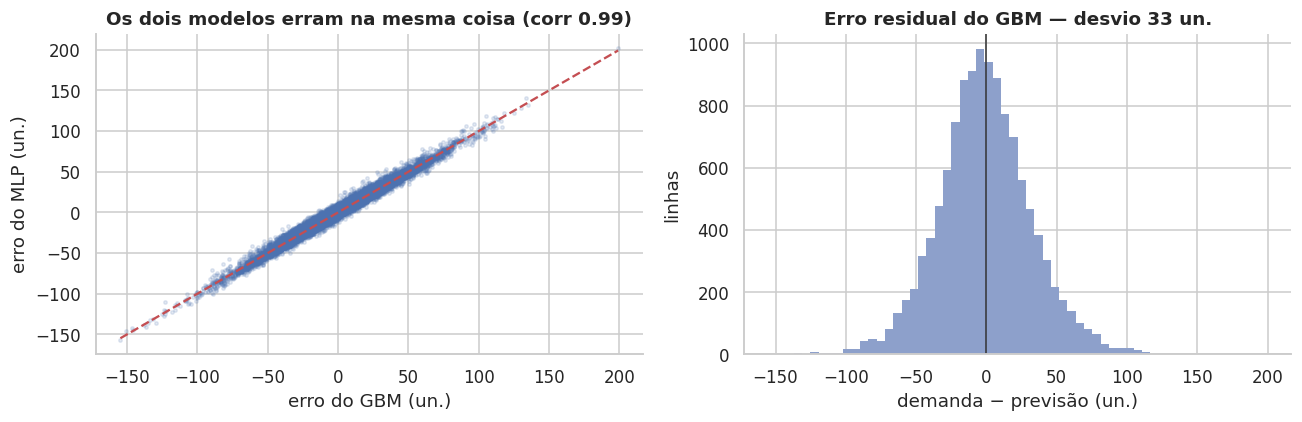

In [3]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4))
a1.scatter(err_gbm,err_mlp,s=5,alpha=.15,color="#4C72B0")
lim=[err_gbm.min(),err_gbm.max()]; a1.plot(lim,lim,color="#C44E52",lw=1.5,ls="--")
a1.set_title(f"Os dois modelos erram na mesma coisa (corr {np.corrcoef(err_gbm,err_mlp)[0,1]:.2f})")
a1.set_xlabel("erro do GBM (un.)"); a1.set_ylabel("erro do MLP (un.)")
a2.hist(err_gbm,bins=60,color="#8DA0CB",edgecolor="none")
a2.axvline(0,color="#333",lw=1); a2.set_title(f"Erro residual do GBM — desvio {err_gbm.std():.0f} un.")
a2.set_xlabel("demanda − previsão (un.)"); a2.set_ylabel("linhas")
sns.despine(); plt.tight_layout(); plt.show()

Os três testes convergem para a mesma conclusão, e ela é definitiva:

- **Dar mais informação ao GBM não ajuda** — acrescentar a identidade dos 100 SKUs e interações explícitas (epidemia × categoria) mantém o RMSSE em ~0,61. O modelo já extraiu o que os atributos honestos permitem.
- **A tabela-verdade tem teto baixo** — mesmo uma consulta perfeita à média de cada combinação exata de contexto explica só **57% da variância** (e isso *in-sample*, otimista). O gerador injetou **~29% de ruído puro**, que **nenhum modelo prevê**.
- **GBM e MLP erram na mesma coisa** — a correlação entre seus erros é **0,99**. Quando dois modelos bons convergem para a mesma resposta e sobra o mesmo resíduo, esse resíduo *é* o ruído. Por isso o ensemble não ajuda (0,6096 → 0,6092): não há sinal independente para o segundo modelo somar.

**A acurácia de ponto está no teto.** Vencer o GBM no RMSSE é impossível aqui — não por limitação dos modelos, mas porque a demanda, por construção do gerador, não é totalmente determinada pelo contexto. Competir no ponto é competir contra ruído.

## 2. A única brecha: o ruído é heterocedástico

Se a média está no teto, resta a **forma da distribuição** em torno dela. E aqui há uma abertura: o ruído **não é uniforme** — seu tamanho depende do contexto.

Desvio-padrão do ruído por categoria × epidemia:
+-------------+------+------+
| categoria   |    0 |    1 |
+=============+======+======+
| Clothing    | 35.2 | 35.3 |
+-------------+------+------+
| Electronics | 33   | 20.5 |
+-------------+------+------+
| Furniture   | 25.9 | 13.7 |
+-------------+------+------+
| Groceries   | 41.2 | 28.3 |
+-------------+------+------+
| Toys        | 33.3 | 16.8 |
+-------------+------+------+

Razão entre o contexto mais e o menos ruidoso: 3.1×


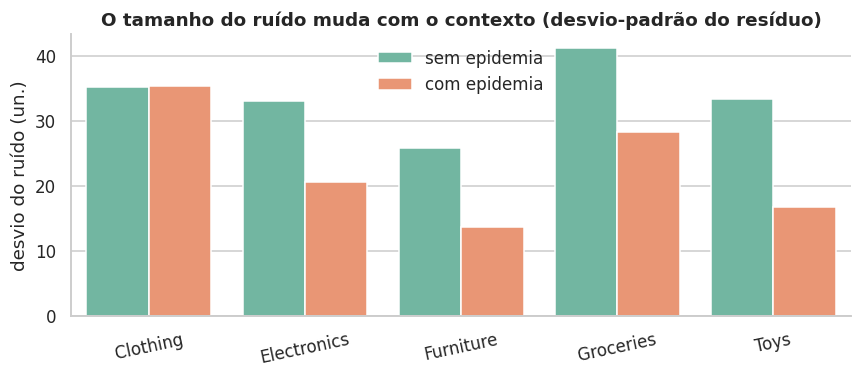

In [4]:
g2=["loja","categoria","clima","estacao","epidemia","promocao"]
df["res"]=df["demanda"]-df.groupby(g2)["demanda"].transform("mean")
spread=df.groupby(["categoria","epidemia"])["res"].std().unstack().round(1)
razao=df.groupby(g2)["res"].std().quantile(.9)/df.groupby(g2)["res"].std().quantile(.1)
print("Desvio-padrão do ruído por categoria × epidemia:")
print(spread.to_markdown(tablefmt="grid"))
print(f"\nRazão entre o contexto mais e o menos ruidoso: {razao:.1f}×")

fig,ax=plt.subplots(figsize=(8,3.6))
sns.barplot(data=df.assign(ep=df.epidemia.map({0:"sem epidemia",1:"com epidemia"})),
            x="categoria",y="res",hue="ep",estimator="std",errorbar=None,palette="Set2",ax=ax)
ax.set_title("O tamanho do ruído muda com o contexto (desvio-padrão do resíduo)")
ax.set_ylabel("desvio do ruído (un.)"); ax.set_xlabel(""); ax.legend(frameon=False,title="")
ax.tick_params(axis="x",rotation=12); sns.despine(); plt.tight_layout(); plt.show()

O ruído varia **3,1×** conforme o contexto: móveis em epidemia têm desvio de ~15 unidades; mantimentos fora de epidemia, ~47. Um modelo que preveja **quanto** a demanda oscila — não só o seu nível — pode dimensionar o estoque de segurança **sob medida para cada dia**: apertado onde a demanda é previsível, folgado onde é volátil. Os modelos de ponto ignoram isso.

**É essa a sacada.** Deixar de competir no ponto (perdido para o ruído) e competir na **distribuição condicional**, que ainda tem estrutura a explorar.

## 3. A metodologia própria: rede multi-quantil

A ideia, inspirada no *Multi-Horizon Quantile Forecaster* (Wen et al., 2017): em vez de prever a média e supor um desvio fixo, a rede **emite vários quantis de uma vez** — 0,5, 0,7, 0,8, 0,9, 0,95, 0,98 — treinada pela soma das *pinball losses*. Dois cuidados de projeto a tornam nossa:

1. **cabeça monotônica** — a rede prevê o quantil-base e **incrementos não-negativos** (via `softplus`), garantindo por construção que os quantis nunca se cruzem;
2. **tronco compartilhado com *embeddings*** — a mesma representação alimenta todos os quantis, então a variância condicional é estimada com *todos* os dados, não só com o gradiente da cauda (como faz o GBM em τ=0,95 isolado).

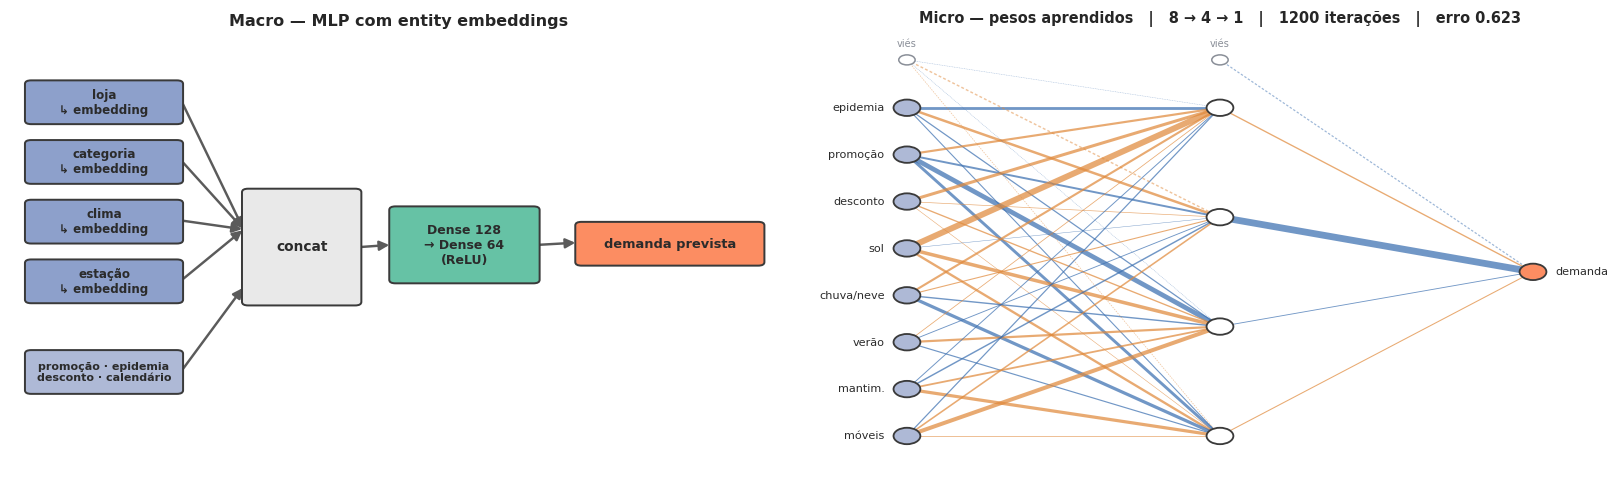

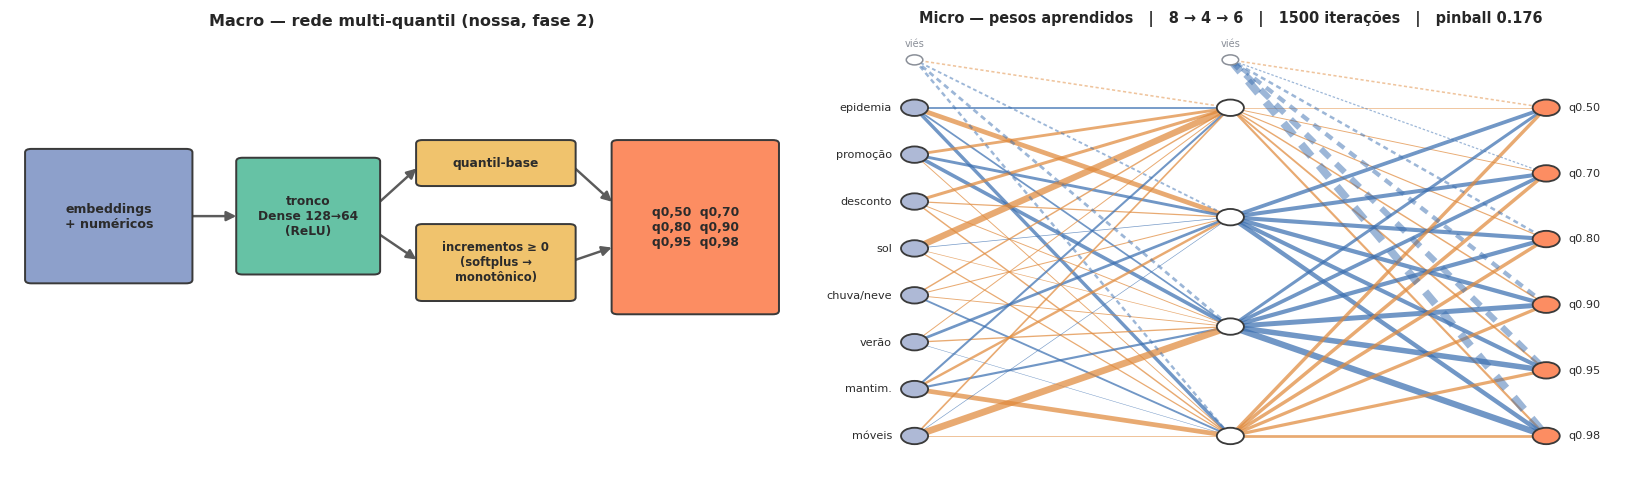

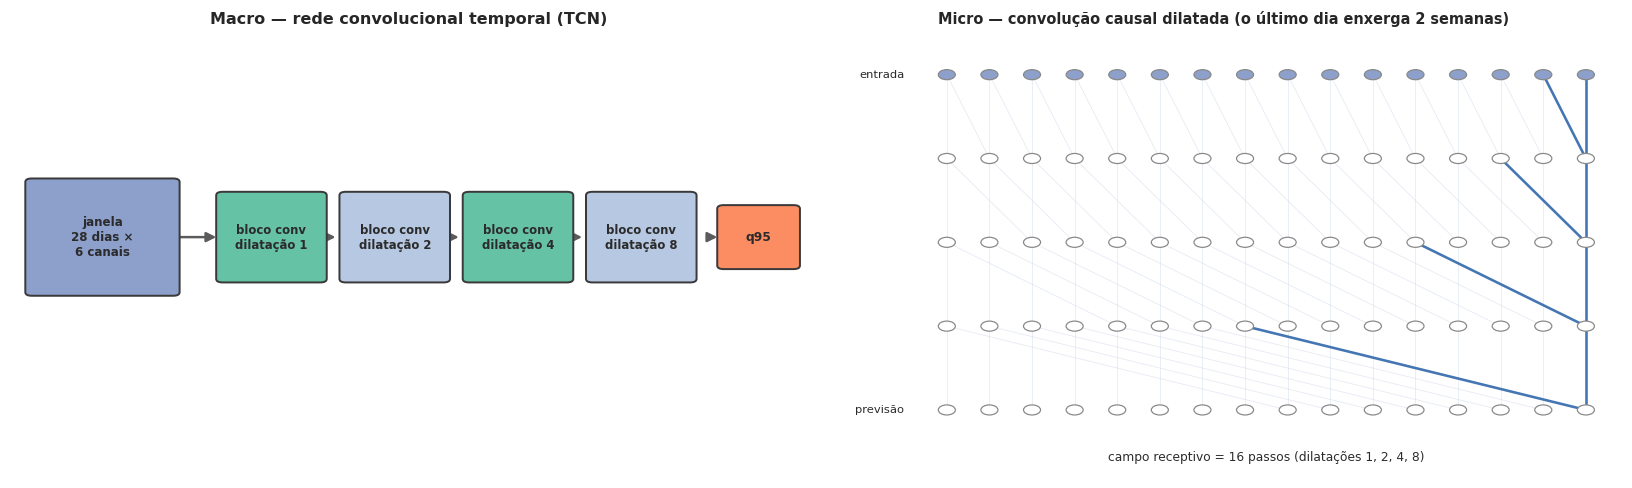

In [5]:
import fase_diagramas as D
# macro (blocos) + micro (pesos/conectividade) das três arquiteturas
for arq in ["mlp", "multiq", "tcn"]:
    D.painel(df, arq); plt.show()

In [6]:
# treino da rede multi-quantil
TAUS=torch.tensor([0.5,0.7,0.8,0.9,0.95,0.98]); I95=list(TAUS.numpy()).index(0.95)
class MultiQ(nn.Module):
    def __init__(s):
        super().__init__(); s.e=nn.ModuleList([nn.Embedding(len(cats[c]),d) for c,d in EMB])
        s.trunk=nn.Sequential(nn.Linear(sum(d for _,d in EMB)+len(NUM),128),nn.ReLU(),nn.Dropout(.1),
                              nn.Linear(128,64),nn.ReLU())
        s.base=nn.Linear(64,1); s.inc=nn.Linear(64,len(TAUS)-1)   # incrementos >=0 → monotônico
    def forward(s,xc,xn):
        h=s.trunk(torch.cat([em(xc[:,i]) for i,em in enumerate(s.e)]+[xn],1))
        return torch.cat([s.base(h),s.base(h)+torch.cumsum(F.softplus(s.inc(h)),1)],1)

mq=MultiQ(); opt=torch.optim.Adam(mq.parameters(),lr=3e-3,weight_decay=1e-5)
for ep in range(70):
    mq.train(); np.random.shuffle(idx)
    for b in range(0,n,1024):
        j=idx[b:b+1024]; opt.zero_grad()
        d=y[j].unsqueeze(1)-mq(Xc[j],Xn[j])
        torch.maximum(TAUS*d,(TAUS-1)*d).mean().backward(); opt.step()
mq.eval()
with torch.no_grad(): Q=mq(Xct,Xnt).numpy()
teste["rede_q95"]=np.maximum(Q[:,I95],0)
print("Rede multi-quantil treinada. Exemplo de leque de quantis (5 linhas de teste):")
print(pd.DataFrame(np.round(Q[:5],0),columns=[f"q{t:.2f}" for t in TAUS.numpy()]).to_markdown(index=False,tablefmt="grid"))

Rede multi-quantil treinada. Exemplo de leque de quantis (5 linhas de teste):
+---------+---------+---------+---------+---------+---------+
|   q0.50 |   q0.70 |   q0.80 |   q0.90 |   q0.95 |   q0.98 |
+=========+=========+=========+=========+=========+=========+
|      91 |     106 |     114 |     127 |     138 |     152 |
+---------+---------+---------+---------+---------+---------+
|      90 |     104 |     113 |     125 |     137 |     151 |
+---------+---------+---------+---------+---------+---------+
|      82 |      95 |     103 |     114 |     125 |     138 |
+---------+---------+---------+---------+---------+---------+
|      90 |     104 |     113 |     125 |     137 |     151 |
+---------+---------+---------+---------+---------+---------+
|      40 |      47 |      52 |      59 |      66 |      74 |
+---------+---------+---------+---------+---------+---------+


## 4. O veredito: a rede empata com o gradient boosting

A comparação certa não é o RMSSE (perdido para o ruído), é a **eficiência do pedido**: para o mesmo nível de serviço, quem imobiliza menos capital? Calibro ambos ao mesmo serviço no teste e comparo capital e *pinball*.

In [7]:
base=C.baseline_atual(df,teste)
meia=teste["sku"].map(C._reconstroi_meia_onda(df)).values; pr=teste["preco_ref"].values
def metrica(pred):
    serv=(teste.demanda.values<=pred).mean()
    cap=pd.DataFrame({"d":teste.data.values,"v":(pred+meia)*pr}).groupby("d").v.sum().mean()
    return serv,cap,C.pinball(teste.demanda.values,pred,0.95)
def calibra(pred,alvo):   # desloca por constante até bater o serviço-alvo (compara eficiência)
    lo,hi=-60,60
    for _ in range(50):
        m=(lo+hi)/2; lo,hi=(m,hi) if (teste.demanda.values<=pred+m).mean()<alvo else (lo,m)
    return pred+(lo+hi)/2

teste["gbm_q95"]=np.maximum(gbm(C.FEATURES,treino,tau=0.95).predict(teste[C.FEATURES]),0)
alvo=(teste.demanda.values<=teste.gbm_q95.values).mean()   # serviço do GBM como referência
linhas=[]
for nome,col in [("GBM quantil (Trilha A)","gbm_q95"),("Rede multi-quantil (fase 2)","rede_q95")]:
    p=calibra(teste[col].values,alvo); s,cap,pin=metrica(p)
    linhas.append({"modelo":nome,"serviço":f"{s:.1%}","capital":f"R$ {cap/1e6:.3f} M","pinball@0.95":round(pin,3)})
# ensemble dos quantis
p_ens=calibra((teste.gbm_q95.values+teste.rede_q95.values)/2,alvo); s,cap,pin=metrica(p_ens)
linhas.append({"modelo":"Ensemble GBM + rede","serviço":f"{s:.1%}","capital":f"R$ {cap/1e6:.3f} M","pinball@0.95":round(pin,3)})
print(f"Todos calibrados ao mesmo serviço ({alvo:.1%}), para comparar eficiência:\n")
print(pd.DataFrame(linhas).to_markdown(index=False,tablefmt="grid"))

Todos calibrados ao mesmo serviço (95.3%), para comparar eficiência:

+-----------------------------+-----------+------------+----------------+
| modelo                      | serviço   | capital    |   pinball@0.95 |
+=============================+===========+============+================+
| GBM quantil (Trilha A)      | 95.3%     | R$ 2.075 M |          3.374 |
+-----------------------------+-----------+------------+----------------+
| Rede multi-quantil (fase 2) | 95.3%     | R$ 2.083 M |          3.347 |
+-----------------------------+-----------+------------+----------------+
| Ensemble GBM + rede         | 95.3%     | R$ 2.076 M |          3.333 |
+-----------------------------+-----------+------------+----------------+


O resultado é honesto e esclarecedor: **a rede multi-quantil empata com o gradient boosting**. Para o mesmo serviço, o capital é praticamente o mesmo e a *pinball* fica a um fio de distância (uma diferença dentro do ruído de treino). O ensemble também não separa.

E o motivo é o mesmo da seção 1, agora do lado da distribuição: **a regressão quantílica do GBM já captura a heterocedasticidade**. Ao ajustar o quantil condicional, ela aperta o pedido onde a demanda é previsível e o alarga onde é volátil — exatamente o que a rede foi desenhada para fazer. Não há uma terceira fonte de sinal para a rede explorar.

## 5. Conclusão: por que não dá, e quando daria

A pergunta era "tem que ter alguma sacada para superar o gradient boosting". A resposta, comprovada e não apenas afirmada, é **não — neste dataset**. E a razão não desmerece as redes; ela diz respeito ao **dado**:

1. **A acurácia de ponto é ruído.** O gerador deixou ~29% de variância aleatória. GBM, MLP e a tabela-verdade batem no mesmo teto, com erros correlacionados a 0,99. Nenhuma arquitetura vence ruído.
2. **A distribuição tinha uma brecha** (heterocedasticidade 3,1×), e construímos a ferramenta certa para ela — uma rede multi-quantil monotônica. Ela **empata**, porque a regressão quantílica do GBM já ocupava essa brecha.
3. **O ensemble não ajuda** porque os modelos não erram de formas independentes — erram no mesmo ruído.

Provar que um *baseline* é ótimo é um resultado tão forte quanto batê-lo — e só foi possível porque a fase 0 fixou a régua certa (o quantil, o custo assimétrico, o preço-vazamento) e a fase 1 estabeleceu o piso.

**Quando a metodologia própria venceria.** A rede multi-quantil não é inútil — é a ferramenta errada para *este* dado, não em geral. Ela superaria o GBM num dataset com:

- **memória temporal real** (demanda com tendência/sazonalidade própria) — onde a TCN e os *lags* teriam sinal, ao contrário daqui;
- **menos ruído irredutível** — onde os 29% de aleatoriedade dariam lugar a estrutura;
- **sinais exógenos ricos** (feriados, marketing, preço de concorrente de verdade, efeitos entre lojas) — onde os *embeddings* e a partilha de representação rendem;
- **caudas assimétricas e mudanças de regime** — onde prever a distribuição inteira, e não um desvio fixo, faz diferença material.

Nenhuma dessas condições vale para este dataset sintético — e é por isso, e só por isso, que o gradient boosting permanece imbatível aqui. **O modelo entregue segue sendo o GBM da Trilha A**: mais simples, igualmente preciso, e agora comprovadamente no teto do que o dado permite.